# Local Friendliness violations with Agents on Quantum Computers

This notebook guides through the full pipeline of the project:
1. Circuit construction
2. Noiseless (ideal) simulation
3. Transpilation for IBM quantum hardware
4. Fake-hardware simulations
5. Real hardware runs on IBM quantum computers


To show 'Local friendliness' violations the following inequality is used:
$$
S = - E_{11} + E_{12} - E_{21} - E_{22} - 2
$$
Extended Wigner's friend scenario (EWFS) circuits including one of the agents as the friend Charlie are built using Qiskit to later be run on quantum computers. Specifically, the minimal scenario with only one friend Charlie is implemented.

## 1. Circuit construction

In this project we work with 4 different agents as the friend in the EWFS, which are defined in detail in the paper.
- Reflex Agent
- Guessing Agent
- Betting Agent
- Always 3/4 Agent

The agent EWFS circuits are constructed from the builders in `ewfs/circuits/agents.py` and plotted in `ewfs/experiments/noiseless_simulation.py` and shown below.

In [8]:
from io import BytesIO
from pathlib import Path
import os
import sys
import warnings

os.environ.setdefault("MPLCONFIGDIR", "/private/tmp/matplotlib-cache")
warnings.filterwarnings("ignore", message="Using qiskit-ibm-runtime with Python 3.9 is deprecated.*")
warnings.filterwarnings("ignore", message="Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.*")

import matplotlib.pyplot as plt
from IPython.display import Image, display

PROJECT_ROOT = next(
    (path for path in [Path.cwd().resolve(), *Path.cwd().resolve().parents] if (path / "ewfs").exists()),
    None,
)
if PROJECT_ROOT is None:
    raise RuntimeError("Could not find the project root containing the 'ewfs' package. Start Jupyter from this repository.")

SRC_ROOT = PROJECT_ROOT / "src"
sys.path = [path for path in sys.path if Path(path or ".").resolve() != SRC_ROOT]
sys.path.insert(0, str(PROJECT_ROOT))
for module_name in list(sys.modules):
    if module_name == "ewfs" or module_name.startswith("ewfs."):
        del sys.modules[module_name]

try:
    import pylatexenc  # noqa: F401
except ModuleNotFoundError as exc:
    raise ModuleNotFoundError(
        "Qiskit's matplotlib circuit drawer needs pylatexenc. Install it in this notebook kernel with: "
        "%pip install pylatexenc==2.10"
    ) from exc

NOTEBOOK_CIRCUIT_FOLD = 100
IBM_BACKEND_NAME = "ibm_marrakesh"

def display_figure_png(fig, dpi=140):
    buffer = BytesIO()
    fig.savefig(buffer, format="png", dpi=dpi, bbox_inches="tight")
    buffer.seek(0)
    display(Image(data=buffer.getvalue()))
    plt.close(fig)

from ewfs.circuits.agents import AGENTS
from ewfs.experiments.noiseless_simulation import (
    make_circuit_plot_figure,
    run_noiseless_simulation,
)
from qiskit_ibm_runtime import QiskitRuntimeService
from ewfs.analysis.lf_violations import S as lf_violation
from ewfs.experiments.ibm_transpilation import (
    make_transpiled_plot_figure,
    transpile_agent_circuit,
    transpiled_circuit_metrics,
)
from ewfs.experiments.fake_hardware import run_fake_hardware_for_backend
from ewfs.analysis.plot_ibm_connectivity import (
    plot_backend_agent_connectivity_simple,
    plot_backend_betting_layout_simple,
)


Reflex Agent


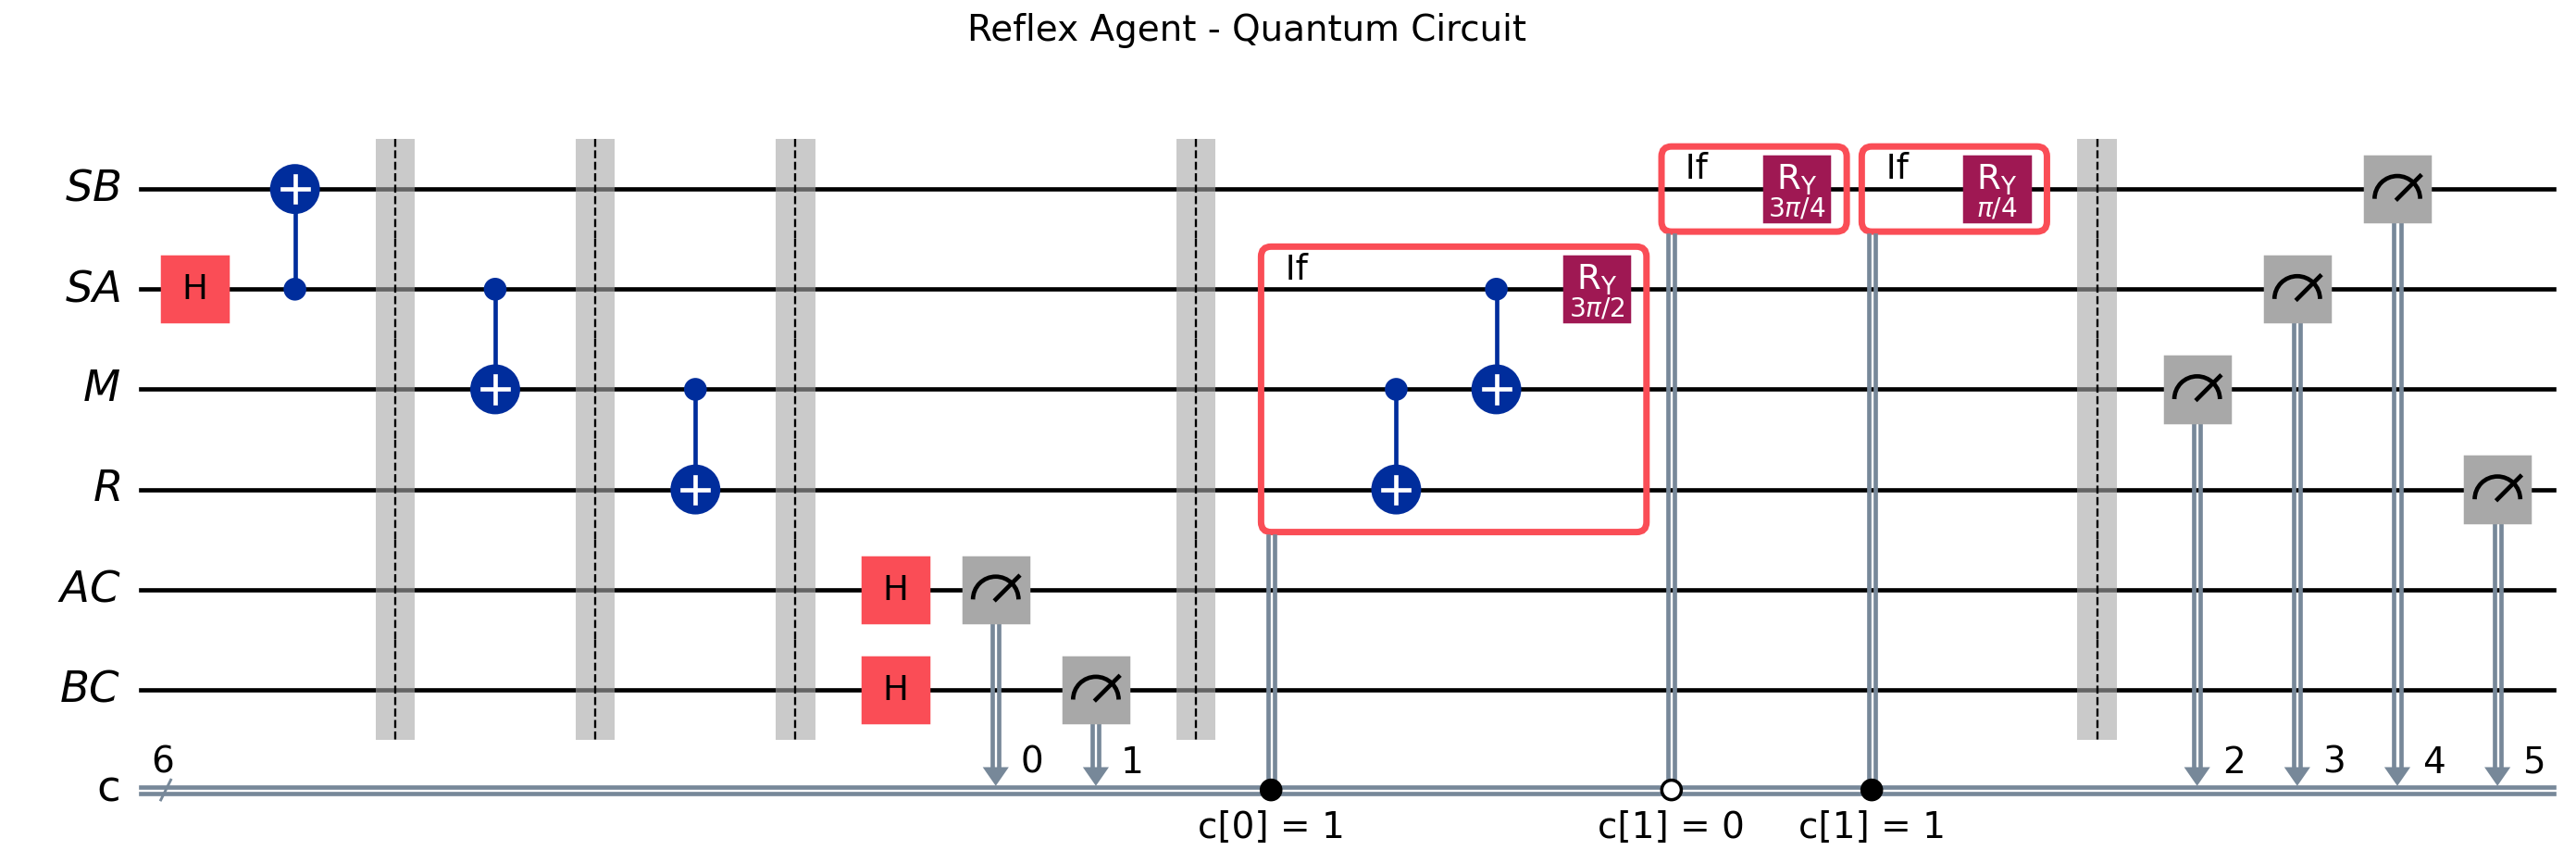

Guessing Agent


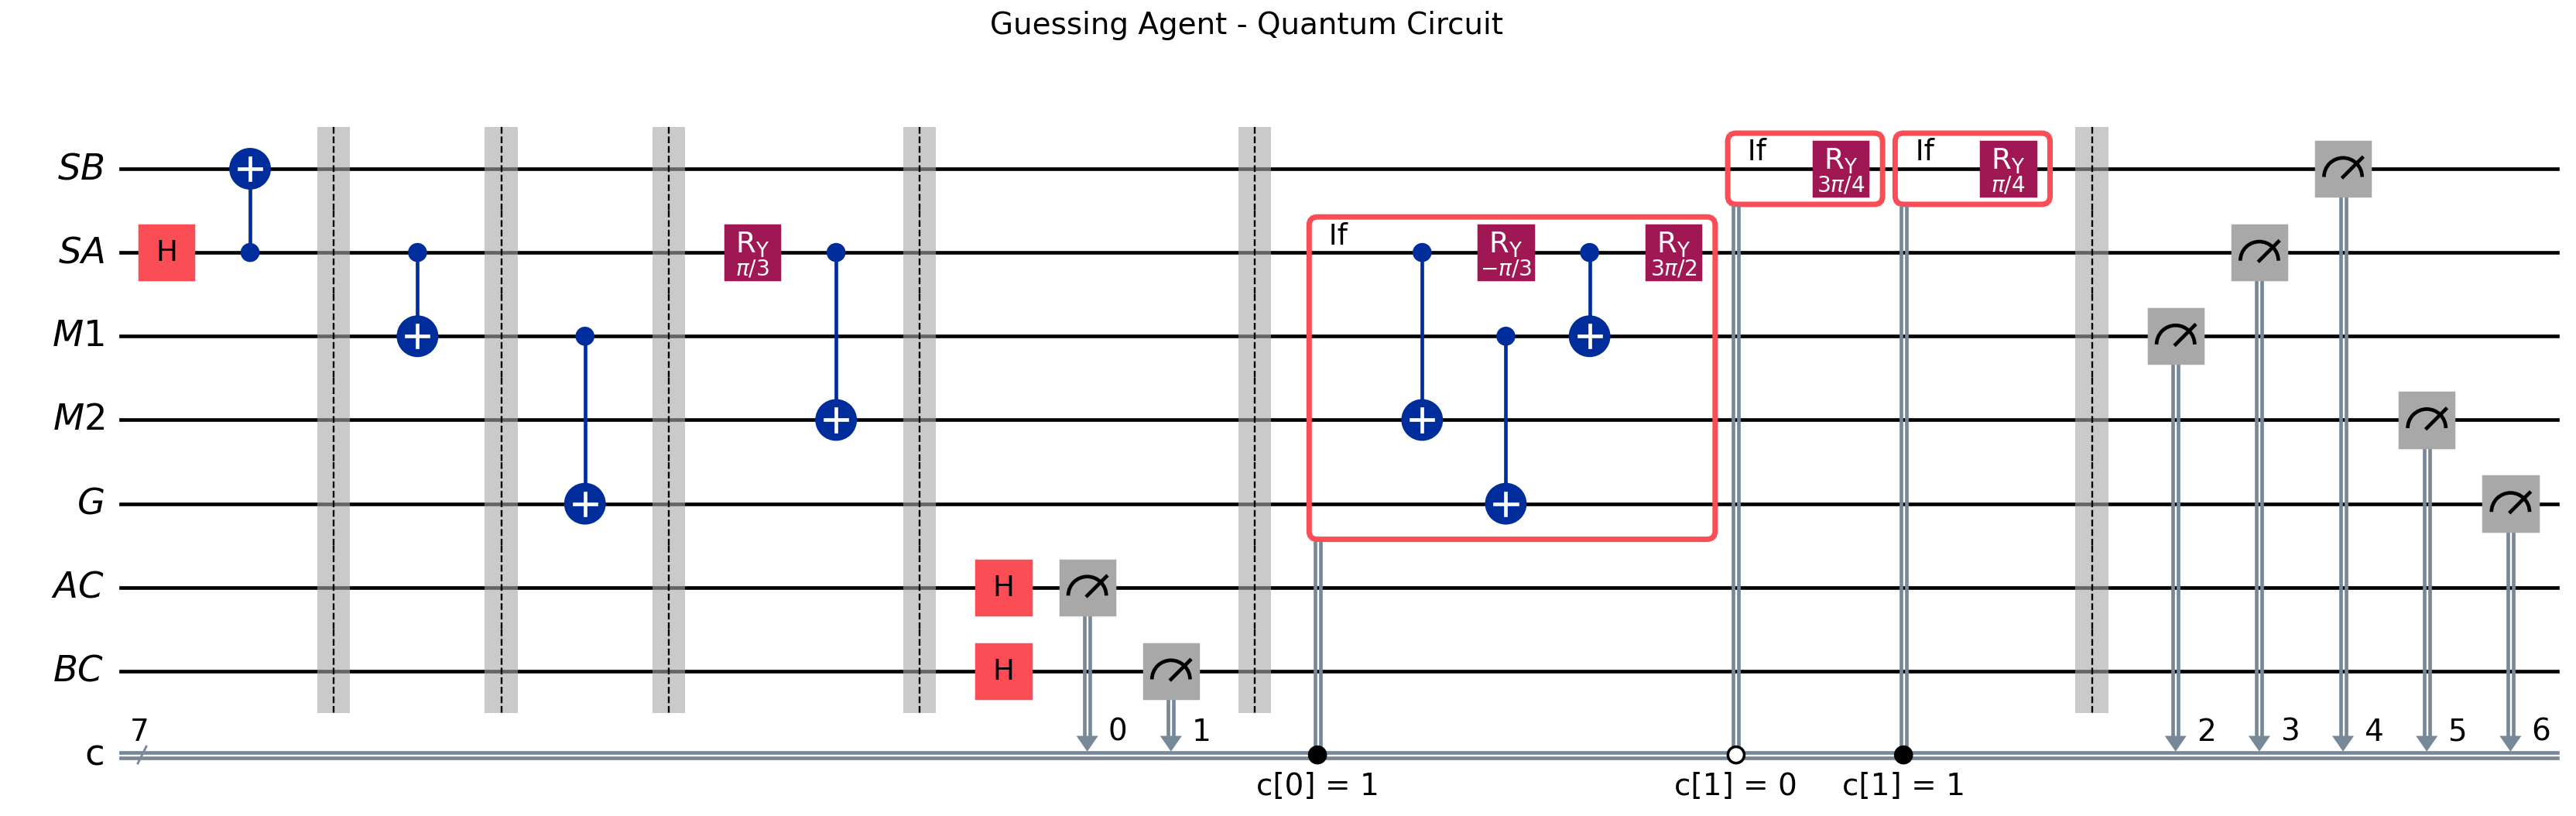

Betting Agent


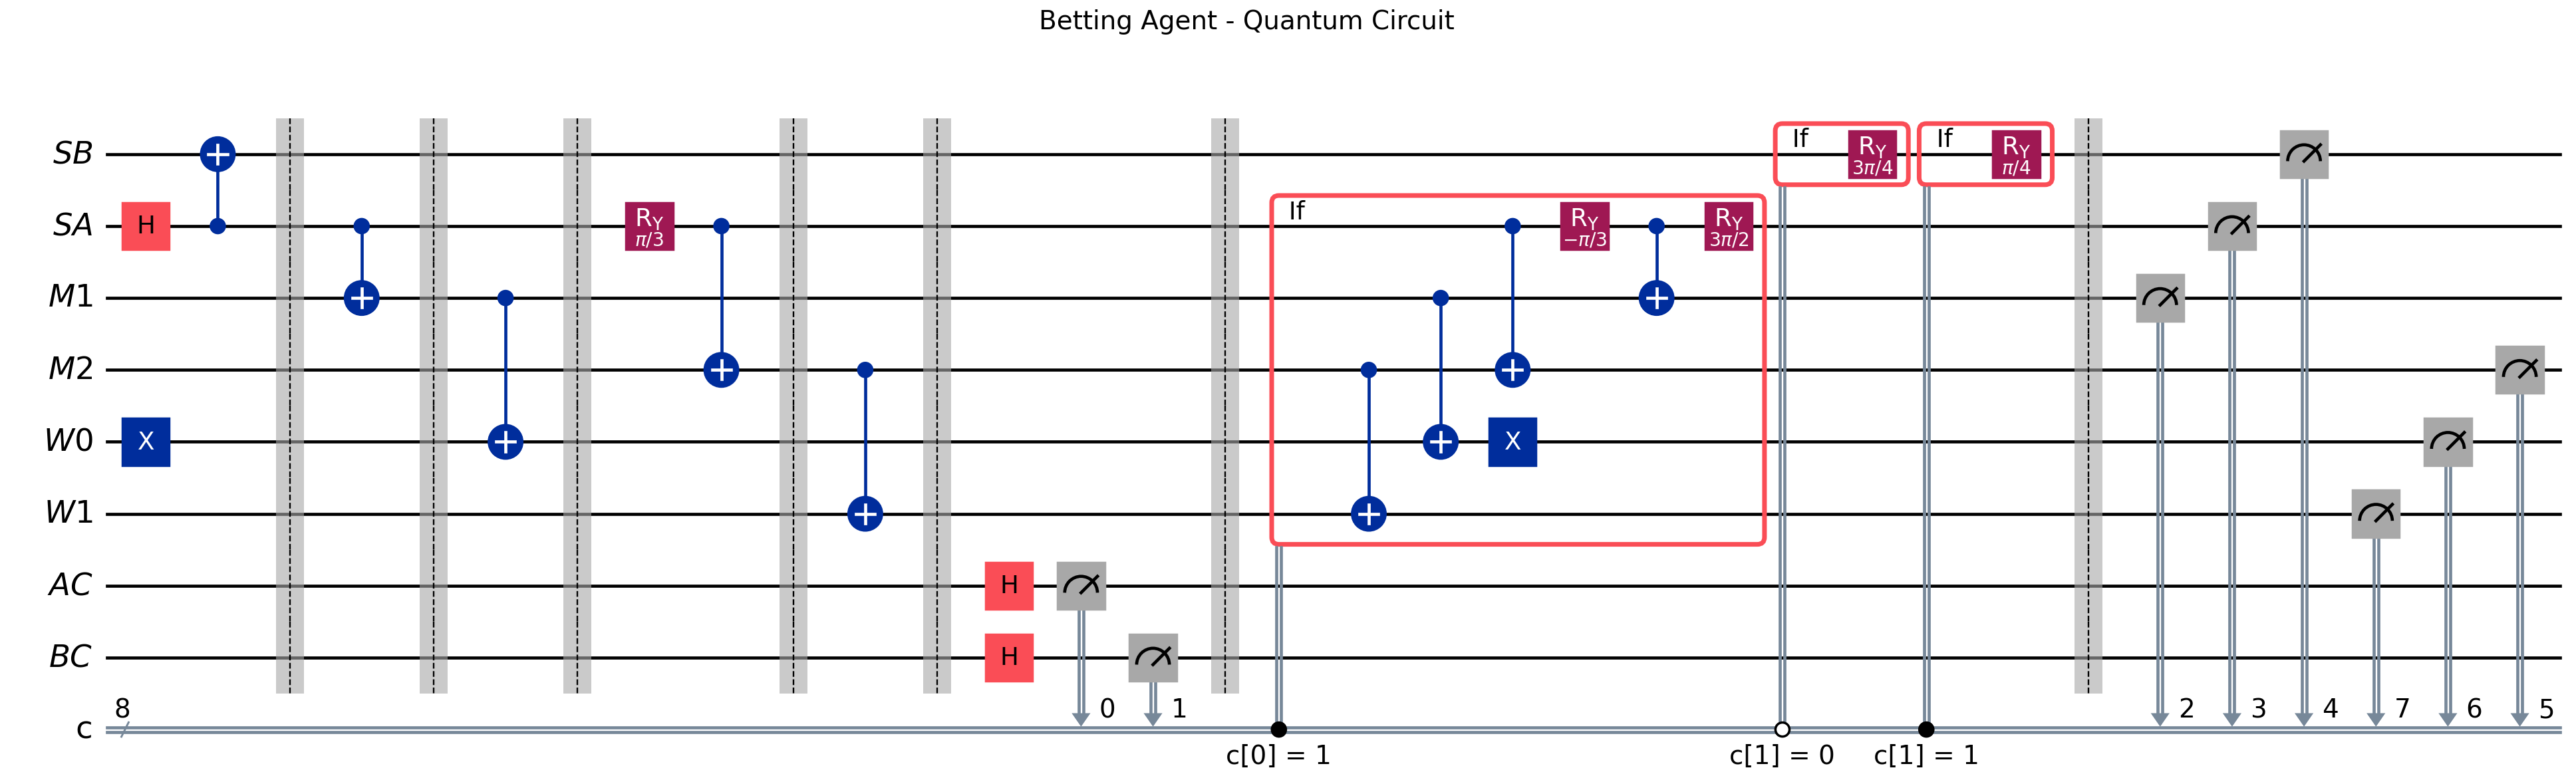

Always 3/4 Agent


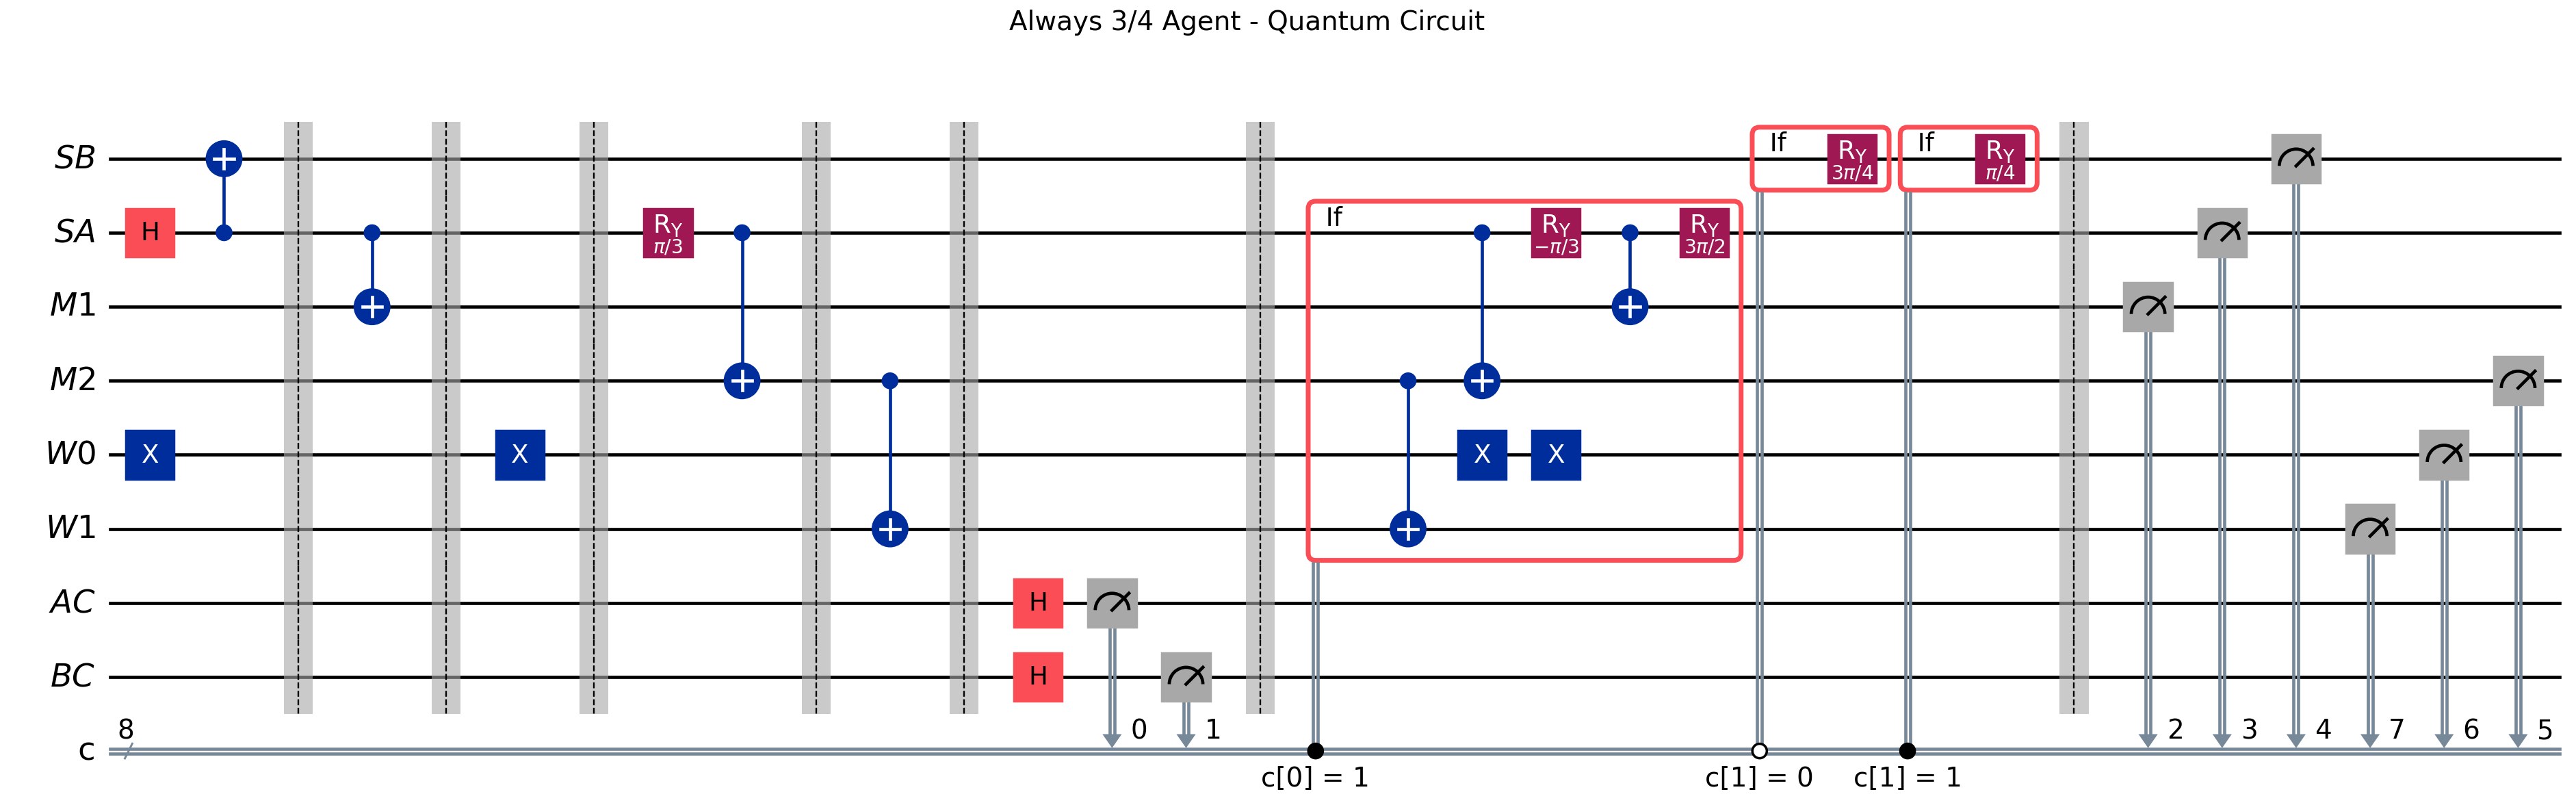

In [9]:
circuits = {}

for agent_name, build_circuit in AGENTS:
    circuit = build_circuit()
    circuits[agent_name] = circuit

    print(agent_name)
    fig = make_circuit_plot_figure(circuit, agent_name, fold=NOTEBOOK_CIRCUIT_FOLD)
    display_figure_png(fig)

## 2. Noiseless simulation

An ideal simulation assuming no noise and using the optimal angles for the scenario should give the maximum violation which is given by
$$
S_{\mathrm{max}} = 2(\sqrt{2} -1) \approx 0.83
$$

The noiseless simulation is performed in `ewfs/experiment/noiseless_simulation.py`and uses the constructed circuits from above. 

The LF violation values for the LF inequality are directly calculated and printed.

In [10]:
noiseless_results = run_noiseless_simulation(
    shots=100_000,
    save=False,
    make_plots=False,
    agent_builders=AGENTS,
)

print("\nLF violation values from the noiseless simulation:")
for agent_name, agent_data in noiseless_results["agents"].items():
    s_value = lf_violation(agent_data["counts"])
    print(f"  {agent_name}: S = {s_value:.4f}")


=== Noiseless simulation ===
Shots: 100000
  Reflex Agent: done
  Guessing Agent: done
  Betting Agent: done
  Always 3/4 Agent: done

LF violation values from the noiseless simulation:
  Reflex Agent: S = 0.8359
  Guessing Agent: S = 0.8443
  Betting Agent: S = 0.8191
  Always 3/4 Agent: S = 0.8291


## 3. Transpilation

To run the circuits on real quantum hardware, the circuit needs to be transpiled to match the architecture of a chosen device.
In this project, we run on the IBM-Marrakesh device, which is a 156 qubit superconducting quantum computer from IBM.

IBM Heron-r2 native gates, which describes a universal basis, are:
\[
\{ \text{id}, R_Z(\theta),\, SX,\, X,\, CZ, R_{ZZ}(\theta), R_X(\theta) \},
\]

Therefore we can translate our circuit into IBM-Marrakesh's native gates using the following relations:
$$
\begin{aligned}
H &= R_Z(\pi)\, SX\, R_Z(\pi), \\[6pt]
X &= X = SX^2, \\[6pt]
R_Y(\theta)
  &= R_Z(\pi)\, SX\, R_Z(\theta)\, SX, \\[6pt]
\mathrm{CNOT}_{c,t}
  &= (I \otimes H)\,
     CZ_{c,t}\,
     (I \otimes H).
\end{aligned}
$$

Furthermore, the IBM-devices are not fully connected, meaning not all qubits can be connected using multi qubit gates. The so-called 'coupling map' of the IBM-Marrakesh hardware device can be accessed via the IBM Quantum platform: quantum.cloud.ibm.com
This coupling map also includes specific calibration values, for example two-qubit errors or readout errors, which are the two that contribute to the noise the most. By comparing the agent connectivity with the coupling map of IBM-Marrakesh one can manually set the qubits to an optimal position (or run a script to optimize the positions). Here it is best to choose a layout with small readout and two-qubit gate error.

Note that it is convenitent to build circuits that match the connectivity of the IBM device one is using. If one wants to transpile a circuit that does not match the coupling map, SWAP gates are needed, which swap the states for neighboring qubits, which resluts in more gates and therefore more noise overall.



The circuits are transpiled for the live IBM Marrakesh backend using the same manual layout and optimization settings as `ewfs/experiments/ibm_transpilation.py`. 

Before transpiling, we visualize the Marrakesh coupling map and the manually selected qubit layouts. The first plot shows the full backend connectivity with the Betting Agent layout highlighted; the second plot zooms in to compare the logical connectivity used by all four agents. Green marks the shared system pair, red marks action/memory/wallet links, and yellow marks the classical choice qubits.

Full backend coupling map with Betting Agent layout highlighted


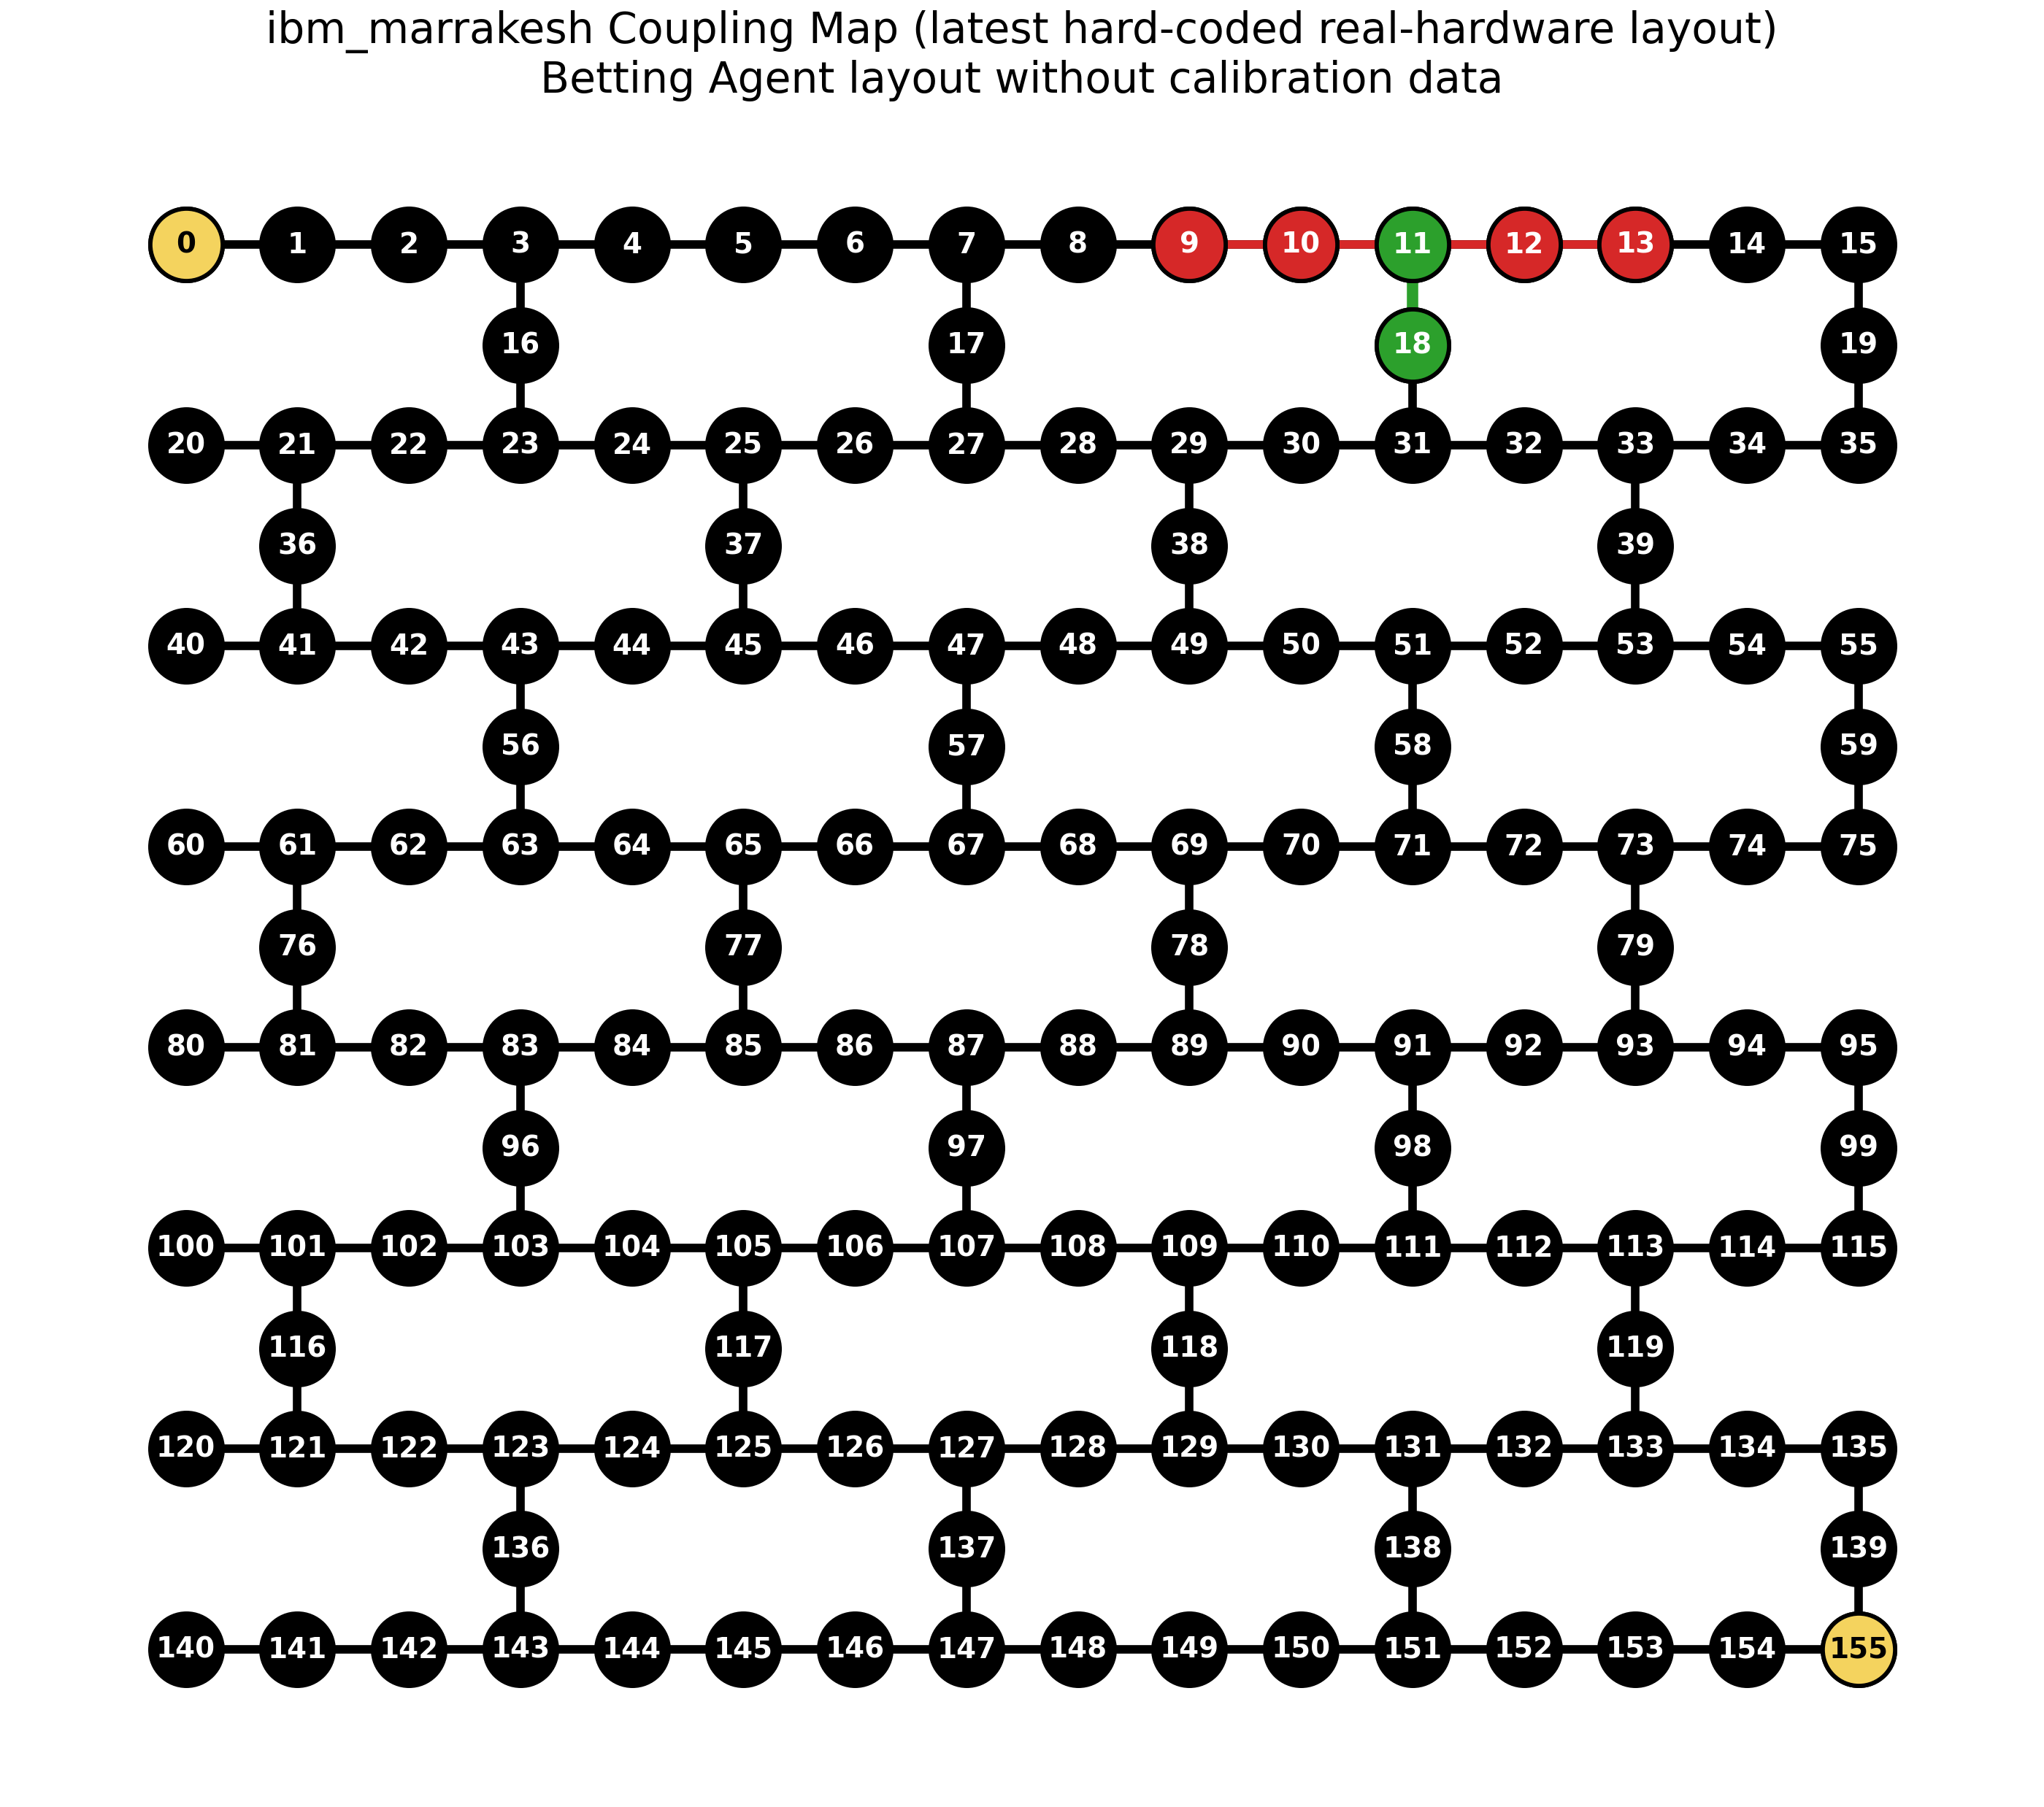

Agent-only connectivity comparison for the selected layouts


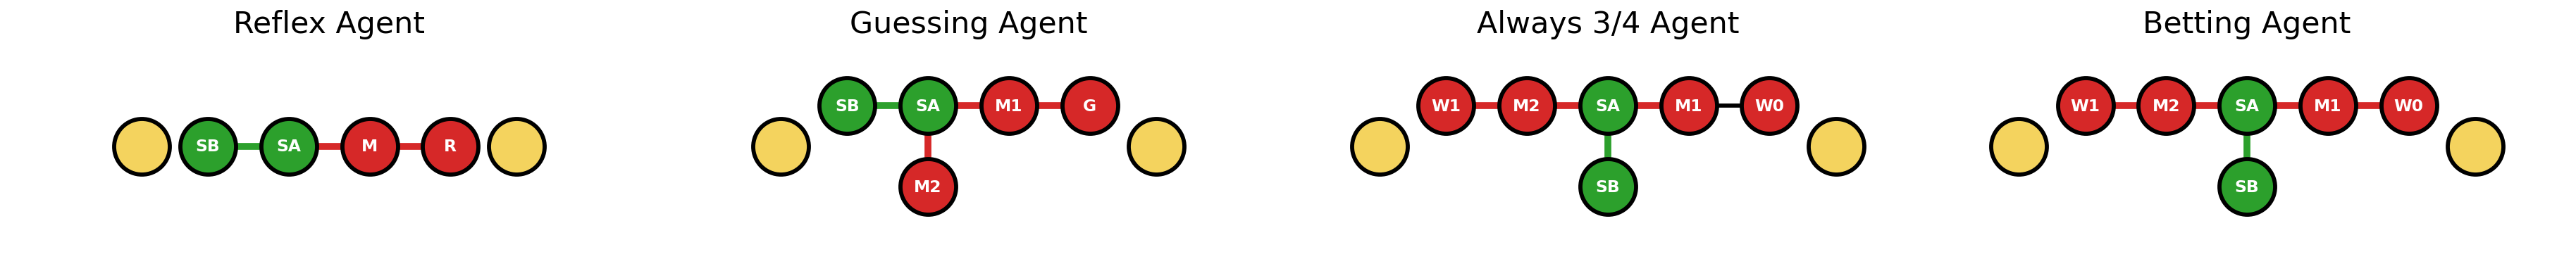

In [11]:
print("Full backend coupling map with Betting Agent layout highlighted")
fig = plot_backend_betting_layout_simple(IBM_BACKEND_NAME, save=False)
display_figure_png(fig)

print("Agent-only connectivity comparison for the selected layouts")
fig = plot_backend_agent_connectivity_simple(IBM_BACKEND_NAME, save=False)
display_figure_png(fig)


qiskit_runtime_service.__init__:WARNING:2026-04-30 15:15:11,401: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: open-instance. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().
qiskit_runtime_service.backends:WARNING:2026-04-30 15:15:11,402: Using instance: open-instance, plan: open


Transpiling for backend: ibm_marrakesh
  Reflex Agent: transpiling
    initial_layout=[10, 11, 12, 13, 0, 155]
    depth=28, cz=3


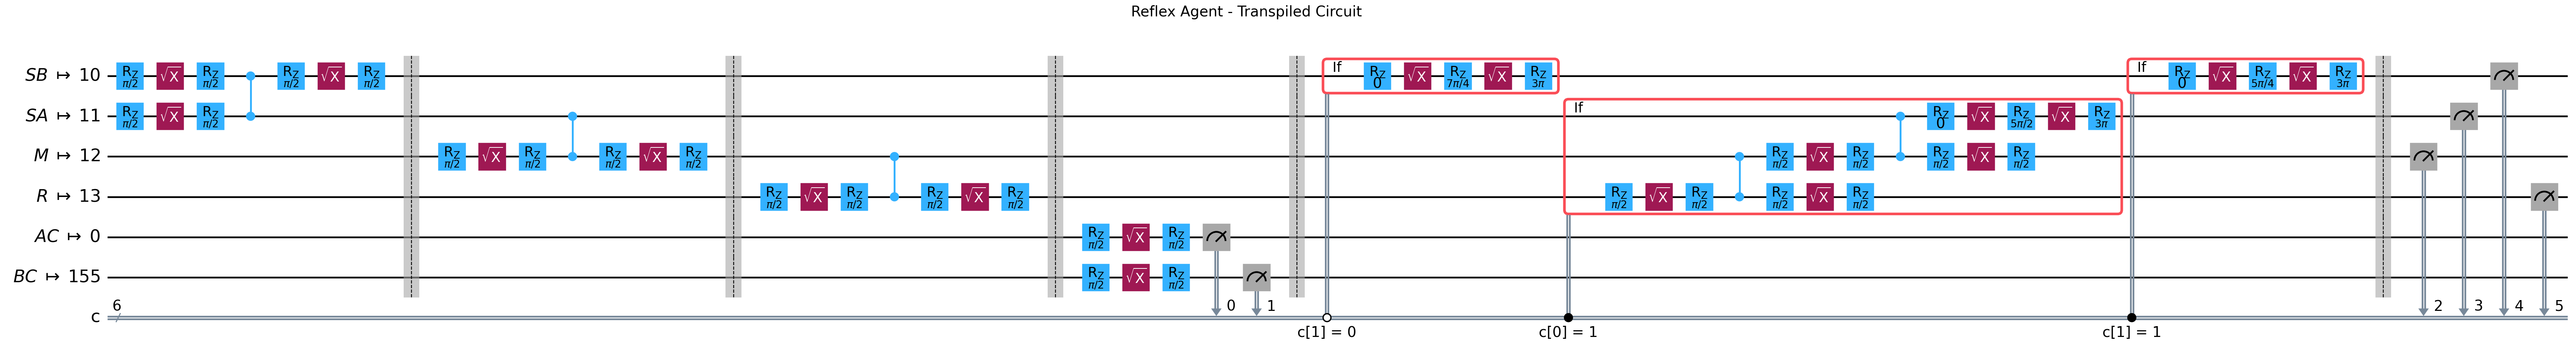

  Guessing Agent: transpiling
    initial_layout=[10, 11, 12, 18, 13, 0, 155]
    depth=37, cz=4


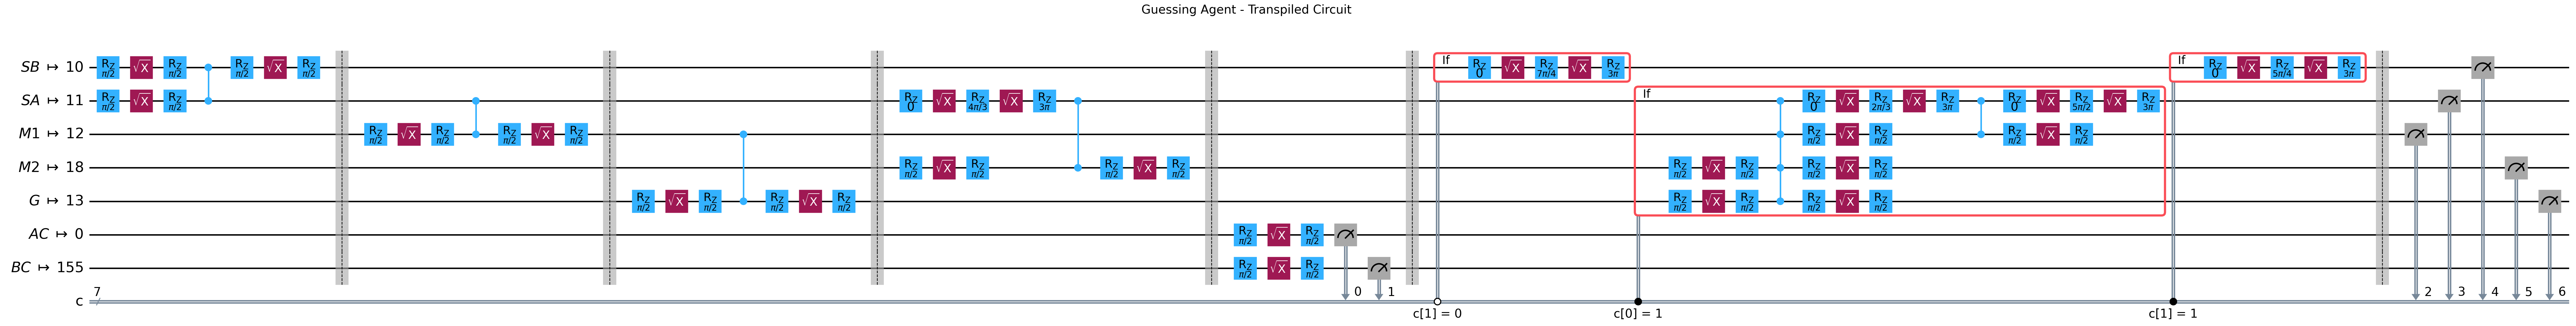

  Betting Agent: transpiling
    initial_layout=[18, 11, 12, 10, 13, 9, 0, 155]
    depth=44, cz=5


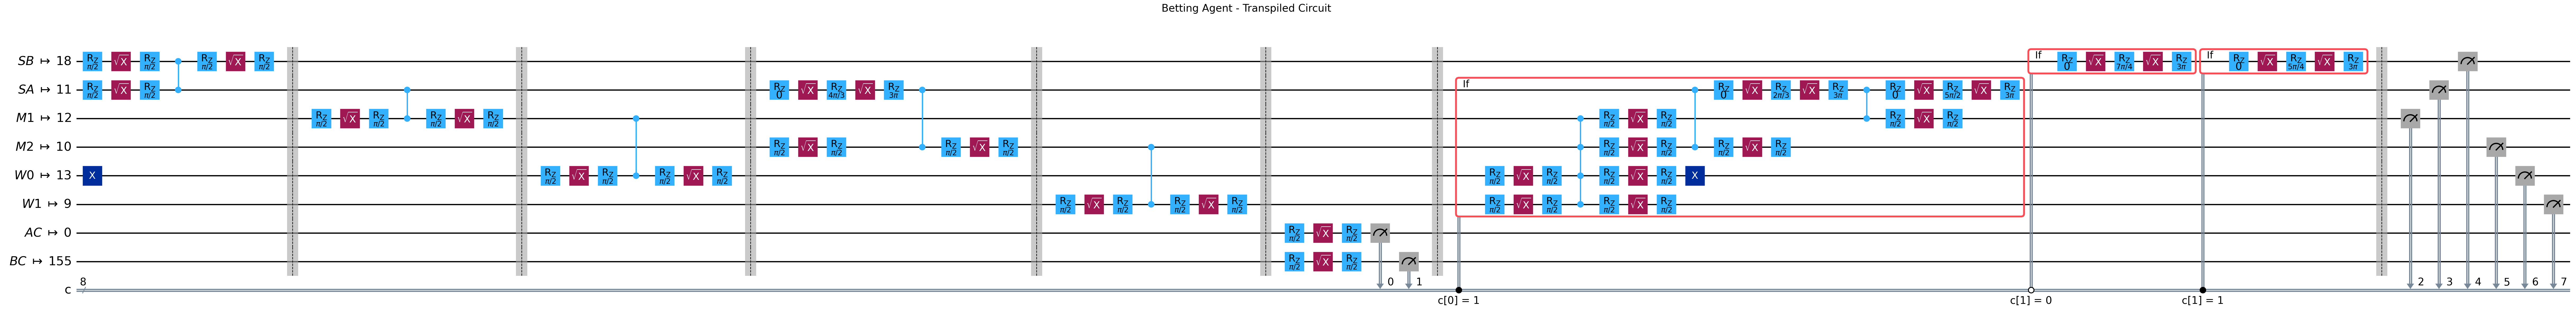

  Always 3/4 Agent: transpiling
    initial_layout=[18, 11, 12, 10, 13, 9, 0, 155]
    depth=38, cz=4


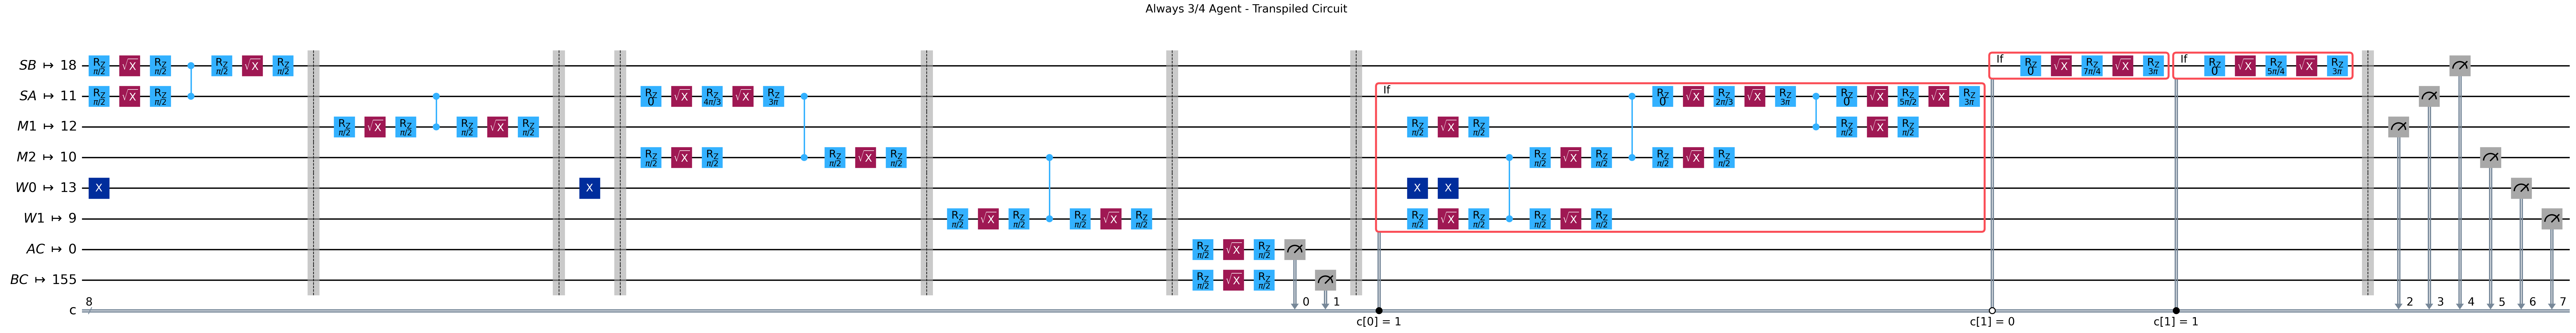

In [12]:
runtime_service = QiskitRuntimeService()
transpilation_backend = runtime_service.backend(IBM_BACKEND_NAME)
transpiled_circuits = {}
transpilation_metrics = []

print(f"Transpiling for backend: {transpilation_backend.name}")
for agent_name, build_circuit in AGENTS:
    original_circuit = circuits.get(agent_name) or build_circuit()
    transpiled_circuit = transpile_agent_circuit(
        agent_name=agent_name,
        build_fn=build_circuit,
        backend=transpilation_backend,
        save_plots=False,
    )
    transpiled_circuits[agent_name] = transpiled_circuit
    transpilation_metrics.append(transpiled_circuit_metrics(agent_name, transpiled_circuit))

    fig = make_transpiled_plot_figure(
        original_circuit,
        transpiled_circuit,
        agent_name,
        fold=NOTEBOOK_CIRCUIT_FOLD,
    )
    display_figure_png(fig)


## 4. Fake-hardware simulation

Before running on real hardware, we simulate our transpiled circuit using a noise model that is built by live calibration data from the IBM-Marrakesh device. Note that these calibrations change over time, so the actual hardware run must be close to the simulation for the simulation to give actual approximations.
Using the Qiskit noise model called 'AerSimulator' a noise model is constructed using backend properties (gate errors, readout errors, T1/T2 times, etc.).

The transpiled circuits are simulated with an Aer noise model generated from the live IBM Marrakesh backend properties.

In [13]:
if "runtime_service" not in globals():
    runtime_service = QiskitRuntimeService()

if "transpilation_backend" not in globals():
    transpilation_backend = runtime_service.backend(IBM_BACKEND_NAME)

if "transpiled_circuits" not in globals():
    transpiled_circuits = {
        agent_name: transpile_agent_circuit(
            agent_name=agent_name,
            build_fn=build_circuit,
            backend=transpilation_backend,
            save_plots=False,
        )
        for agent_name, build_circuit in AGENTS
    }

fake_hardware_results = run_fake_hardware_for_backend(
    backend=transpilation_backend,
    transpiled_by_agent=transpiled_circuits,
    shots=10_000,
    save=False,
)

print("\nLF violation values from the fake-hardware simulation:")
for agent_name, agent_data in fake_hardware_results["agents"].items():
    s_value = lf_violation(agent_data["counts"])
    print(f"  {agent_name}: S = {s_value:.4f}")



=== Fake hardware simulation ===
Backend: ibm_marrakesh
Shots: 10000
  Reflex Agent: done
  Guessing Agent: done
  Betting Agent: done
  Always 3/4 Agent: done

LF violation values from the fake-hardware simulation:
  Reflex Agent: S = 0.6006
  Guessing Agent: S = 0.6491
  Betting Agent: S = 0.5517
  Always 3/4 Agent: S = 0.5679


## 5. Real hardware runs

Real IBM hardware jobs are not submitted from this demo notebook, since running them requires an IBM API key and access to the selected backend. Instead, this section loads all saved LF-violation results from `data/paperdata/real_hardware` and prints the average LF value over the paperdata runs.

In [14]:
import json

real_hardware_paperdata_dir = PROJECT_ROOT / "data" / "paperdata" / "real_hardware"
real_hardware_lf_paths = sorted(real_hardware_paperdata_dir.glob("*/lf_violations/lf_violations.json"))
if not real_hardware_lf_paths:
    raise FileNotFoundError(f"No saved LF-violation files found in {real_hardware_paperdata_dir}")

real_hardware_s_values = {agent_name: [] for agent_name, _ in AGENTS}
for lf_path in real_hardware_lf_paths:
    with open(lf_path, "r", encoding="utf-8") as f:
        lf_results = json.load(f)
    for agent_name, _ in AGENTS:
        real_hardware_s_values[agent_name].append(float(lf_results["agents"][agent_name]["S"]))

print(f"Averaged over {len(real_hardware_lf_paths)} saved real-hardware paperdata runs")
print("Average LF violation values from saved real-hardware paperdata:")
for agent_name, _ in AGENTS:
    values = real_hardware_s_values[agent_name]
    mean_s = sum(values) / len(values)
    print(f"  {agent_name}: mean S = {mean_s:.4f}")


Averaged over 10 saved real-hardware paperdata runs
Average LF violation values from saved real-hardware paperdata:
  Reflex Agent: mean S = 0.4652
  Guessing Agent: mean S = 0.4347
  Betting Agent: mean S = 0.3059
  Always 3/4 Agent: mean S = 0.3784
